# The RNN never learned the policy: it learned a slow drift toward the wrong certainty

*A standalone study of one finding from the FSC ↔ tinyRNN pipeline.*

## The task and the two models

The task is about as simple as a decision task gets. On each trial you pick one of two arms and you
either win or lose. The rule behind the data is **win-stay/lose-shift** (WSLS): if your last choice
won, pick it again; if it lost, switch. One bit of memory covers it.

We fit two small models to the same 1000 sessions of that behavior.

- A **Finite State Controller** (FSC): a few discrete memory states plus a lookup table saying which
  state to move to given the last `(action, observation)`. Two states are enough here.
- A **GRU** (from tinyRNN): a recurrent network whose memory is a short list of real numbers,
  updated by trained weights. We use the smallest one that still explains the data.

## The finding

On ordinary trials the two models are the same. Both reproduce WSLS, and both match the data's rates
to about 0.002. Underneath, they learned different things. The FSC learned the rule itself, a lookup,
so "you won, so stay" holds no matter how much evidence piles up. The GRU learned an approximation
that is right where the data lives and wrong outside it.

## The experiment: the off-manifold probe

Take a fitted RNN and feed it the same trial over and over, "you picked arm A and you won", `k`
times in a row. After each repeat, ask how sure it is that it will stay on A. WSLS forces one
answer: 1.0, at every `k`, forever. More winning evidence cannot make staying less attractive.

The RNN gives that answer only over the streak lengths it was trained on. In these sessions a win
streak runs 1.7 trials on average and 99% of them are over by 11, and out there the model still
reads 0.95 or better. By 28, the single longest streak in the whole dataset, it is down to 0.71.
Push further and it drops through 0.5 and out the other side. Its memory never settles where the rule requires. It slides toward a resting state whose
readout is the wrong answer. The FSC, asked the same question, says 1.0 at every `k` and never moves.

## Why this matters

The rule is one bit and we handed the network 1000 sessions. The FSC captured it with two states.
The smaller GRUs encoded "always stay" as a temporary state tuned to the streak lengths they saw in
training, so the behavior they produce matches the data while the rule they hold inside does not.
That gap is the point. Fitting behavior and learning a policy are two different achievements, and
only a probe that leaves the data can tell them apart.

## Roadmap

- §0 reload the committed fits, reduce everything to plain numpy.
- §1 do the two models read the same on ordinary trials? Deviation-from-data bars.
- §2 the probe: what happens to `P(stay)` under a run of wins? The hero decay curve.
- §3 what does the internal state do while confidence falls? Hidden trajectory and step size.
- §4 where does the state end up, and why did training not catch it? Fixed-point map and table.
- §5 is it just too few units? The per-size grid.
- §6 what held and what drifted across the five datasets. Small-multiple grid and L1.
- §7 what this adds up to.

> **Reproducibility.** This notebook stands alone. It reloads each dataset's committed FSC and GRU
> fits from `fitted_models/<dataset>/`, re-derives one GRU step in pure numpy, and computes every
> figure live. It needs the two upstream repos already cloned on disk (`tinyRNN/`,
> `FSC-inference-MAPSO/`), the same requirement as the main pipeline. It does not rerun Section 0 of
> that pipeline, and it trains nothing.

## 0. Setup: reload the fits, reduce everything to plain numpy

One cell does the heavy lifting. It loads every dataset's committed FSC and GRU fits, pulls the
trained GRU weights out into numpy, and precomputes what the later sections plot: the probe
(`P(stay)` vs `k`), the hidden-state trajectories, and the resting states. Everything after this
runs in plain numpy and matplotlib, so the figures redraw fast and stay easy to check.

Two mechanics come straight from the main pipeline, which documents them:

- **Import switching** (`_use_fsc_path`, `_use_tinyrnn_path`): the two repos ship modules with the
  same names, so the code swaps `sys.path` and clears stale modules before importing from either
  side.
- **The pure-numpy GRU step** (`gru_step`): torch's `nn.GRU` hands back only the hidden state, so we
  rewrite one step by hand to expose the update, reset, and new gates that §3 and §4 need. The main
  pipeline's §4.3 checks it against the library bit for bit.

In [57]:
# --- 0.1 -- imports, path switching, pure-numpy GRU, and the loaders -----------------------
import sys, os, glob, pickle, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Cross-version pandas pickle compat: the det_init model summaries were pickled with a newer
# pandas whose string arrays reduce to a 2-tuple state; teach this build to accept it. No-op
# for same-version pickles, so it is always safe to install. (Same shim as pipeline §0.)
import pandas.core.arrays.string_ as _pd_str
from pandas.core.arrays._mixins import NDArrayBacked as _NDArrayBacked
def _compat_string_setstate(self, state):
    if isinstance(state, tuple) and len(state) == 2 and isinstance(state[1], np.ndarray):
        state = (state[0], state[1], {})
    return _NDArrayBacked.__setstate__(self, state)
_pd_str.StringArray.__setstate__ = _compat_string_setstate

REPO         = os.path.abspath(".")
FSC_SRC      = os.path.abspath("FSC-inference-MAPSO/src")
TINYRNN_ROOT = os.path.abspath("tinyRNN")
_COLLIDING   = ("utils", "FSC", "MAPSO", "parametrizations", "environments", "DiscreteObs")

def _use_fsc_path():
    if TINYRNN_ROOT in sys.path: sys.path.remove(TINYRNN_ROOT)
    if FSC_SRC not in sys.path:  sys.path.insert(0, FSC_SRC)
    for m in list(sys.modules):
        if m.split(".")[0] in _COLLIDING: del sys.modules[m]

def _use_tinyrnn_path():
    if FSC_SRC in sys.path:          sys.path.remove(FSC_SRC)
    if TINYRNN_ROOT not in sys.path: sys.path.insert(0, TINYRNN_ROOT)
    for m in list(sys.modules):
        if m.split(".")[0] in _COLLIDING: del sys.modules[m]

# Datasets, ordered LEAST -> MOST deterministic (the "determinism spectrum" of §6). Each is a
# WSLS variant; committed fits live under fitted_models/<name>/. `original` uses a legacy folder.
DATASETS      = ["rwsls_det_init", "lwsls_det_init", "random_init", "det_init", "original"]
DATASET_FILES = {
    "rwsls_det_init": "datasets/rwsls_actions_observations_det_init.npz",
    "lwsls_det_init": "datasets/lwsls_actions_observations_det_init.npz",
    "random_init":    "datasets/wsls_actions_observations_random_init.npz",
    "det_init":       "datasets/wsls_actions_observations_det_init.npz",
    "original":       "datasets/wsls_actions_observations.npz",
}
EXP_OVERRIDE = {"original": "exp_my_behavior"}   # trained before the exp_<name> convention
H_LIST       = [2, 4, 8]                          # the size sub-study, same as pipeline §4.2
KMAX         = 80                                 # probe length for the decay curves
KGRID        = np.arange(KMAX + 1)                # k = 0 (h=h0) .. KMAX

# ---- one GRU step in numpy, with the three gates exposed (torch nn.GRU equations) ----
def _sigmoid(x): return 1.0 / (1.0 + np.exp(-x))
def _softmax(z):
    z = np.asarray(z, float); z = z - z.max(); e = np.exp(z); return e / e.sum()

def gru_step(h, x, P):
    """Returns (h', {reset r, update z, new n}). h' = (1-z)*n + z*h;  z~1 hold, z~0 overwrite."""
    H  = P["H"]
    gi = P["W_ih"] @ x + P["b_ih"]
    gh = P["W_hh"] @ h + P["b_hh"]
    r  = _sigmoid(gi[:H]    + gh[:H])
    z  = _sigmoid(gi[H:2*H] + gh[H:2*H])
    n  = np.tanh( gi[2*H:]  + r * gh[2*H:])
    return (1 - z) * n + z * h, {"reset": r, "update": z, "new": n}

def rnn_action_probs(h, P):   # readout: softmax(Linear(h))
    return _softmax(h @ P["lin_W"].T + P["lin_b"])

def extract_gru_params(agent):
    net = agent.model
    p = {k: v.detach().cpu().numpy() for k, v in net.rnn.named_parameters()}
    return {"W_ih": p["weight_ih_l0"], "W_hh": p["weight_hh_l0"],
            "b_ih": p["bias_ih_l0"],   "b_hh": p["bias_hh_l0"],
            "lin_W": net.lin.weight.detach().cpu().numpy(),
            "lin_b": net.lin.bias.detach().cpu().numpy(), "H": net.hidden_dim}

def encode_input(a, y, A, Y):     # one-hot(action) | one-hot(obs), as in pipeline §3.1
    x = np.zeros(A + Y); x[a] = 1.0; x[A + y] = 1.0; return x

# ---- loaders -------------------------------------------------------------------------------
def load_dataset(name):
    raw = np.load(os.path.join(REPO, DATASET_FILES[name]))
    ra, ro = raw["actions"], raw["observations"]
    n_total = ra.shape[0]
    n_use = min(1000, n_total)
    idx = (np.arange(n_total) if n_use == n_total
           else np.random.default_rng(0).choice(n_total, n_use, replace=False))
    ActSpace = np.array(sorted(set(ra[idx].flatten().tolist())))
    ObsSpace = np.array(sorted(set(ro[idx].flatten().tolist())))
    a2i = {v: i for i, v in enumerate(ActSpace)}
    o2i = {v: i for i, v in enumerate(ObsSpace)}
    sessions = [{"actions":      np.array([a2i[a] for a in ra[i]], dtype=int),
                 "observations": np.array([o2i[o] for o in ro[i]], dtype=int)} for i in idx]
    win_idx  = int(np.where(ObsSpace == 1)[0][0]) if 1 in ObsSpace.tolist() else len(ObsSpace) - 1
    lose_idx = 1 - win_idx if len(ObsSpace) == 2 else 0
    return dict(name=name, ActSpace=ActSpace, ObsSpace=ObsSpace, A=len(ActSpace), Y=len(ObsSpace),
                win_idx=win_idx, lose_idx=lose_idx, sessions=sessions)

def load_rnn(name, A, Y, exp_suffix=""):
    """Restore archive->live if needed, then load GRU params at each H (best trainval loss)."""
    _use_tinyrnn_path()
    exp = EXP_OVERRIDE.get(name, f"exp_{name}") + exp_suffix
    live = f"files/saved_model/{exp}"
    arch = os.path.join(REPO, "fitted_models", name, "rnn", exp)
    cwd = os.getcwd(); os.chdir("tinyRNN")
    try:
        if os.path.isdir(arch) and not os.path.isdir(live): shutil.copytree(arch, live)
        if not os.path.isdir(live): return {}
        from agents import Agent
        from analyzing_experiments.analyzing_perf import select_final_rnn_perf
        _, summary, _ = select_final_rnn_perf(exp, return_dim_est=True, verbose=False)
        out = {}
        for H in H_LIST:
            rows = summary[summary["hidden_dim"] == H].sort_values("trainval_loss")
            if len(rows) == 0: continue
            cfg = {"agent_type": "RNN", "rnn_type": "GRU", "input_dim": A + Y, "hidden_dim": H,
                   "output_dim": A, "device": "cpu", "output_h0": True, "trainable_h0": False,
                   "readout_FC": True, "one_hot": False, "seed": 0}
            ag = Agent("RNN", config=cfg); ag.load(str(rows.iloc[0]["model_path"]))
            out[H] = extract_gru_params(ag)
        return out
    finally:
        os.chdir(cwd)

def load_fsc(name):
    _use_fsc_path()
    paths = glob.glob(os.path.join(REPO, f"fitted_models/{name}/fsc/best_fsc_M*.pkl"))
    if not paths: return None
    m = int(paths[0].split("_M")[-1].split(".pkl")[0])
    with open(paths[0], "rb") as f: fsc = pickle.load(f)
    fsc.set_mode("generation")
    return dict(M=m, rho=np.asarray(fsc.get_rho()),
                TMat=np.asarray(fsc.get_TMat()), pol=np.asarray(fsc.get_action_policy()))

print("Setup 0.1 OK: helpers defined.")

Setup 0.1 OK: helpers defined.


In [58]:
# --- 0.2 -- The probe + fixed-point analysis, run once for every dataset -------------------
# For each dataset we cache, per hidden size H and per starting arm a0:
#   * pstay[k]    -- P(stay on a0) after k consecutive (chose a0, won) trials, from h0=0
#   * hidden[k]   -- the hidden state at each k (for §3)
#   * gates[k]    -- update/reset/new gate vectors at each step (cached for reference)
#   * fp_pstay    -- P(stay) at the ASYMPTOTIC fixed point (k -> infinity)
#   * spec_radius -- spectral radius of the map's Jacobian at that fixed point (<1 => stable)
# and the FSC's own P(stay) vs k (a discrete-state belief recursion). Also the empirical +
# model win-stay / lose-shift rates for the on-manifold check in §1.

def rnn_probe(P, a0, y_idx, A, Y, kmax=KMAX):
    x = encode_input(a0, y_idx, A, Y)
    h = np.zeros(P["H"])
    hidden = [h.copy()]; gates = []; pstay = [rnn_action_probs(h, P)[a0]]
    for _ in range(kmax):
        h, g = gru_step(h, x, P); hidden.append(h.copy()); gates.append(g)
        pstay.append(rnn_action_probs(h, P)[a0])
    return dict(pstay=np.array(pstay), hidden=np.array(hidden), gates=gates)

def rnn_fixed_point(P, a0, y_idx, A, Y, n_iter=4000, eps=1e-6):
    x = encode_input(a0, y_idx, A, Y)
    h = np.zeros(P["H"])
    for _ in range(n_iter): h, _ = gru_step(h, x, P)
    J = np.zeros((P["H"], P["H"]))
    for j in range(P["H"]):
        hp = h.copy(); hp[j] += eps
        hpn, _ = gru_step(hp, x, P); J[:, j] = (hpn - h) / eps
    return dict(pstay=float(rnn_action_probs(h, P)[a0]),
                spec_radius=float(np.max(np.abs(np.linalg.eigvals(J)))))

def fsc_probe(FS, a0, y_idx, kmax=KMAX):
    b = FS["rho"].copy(); pstay = [float((b @ FS["pol"])[a0])]
    for _ in range(kmax):
        bn = b @ FS["TMat"][y_idx, :, :, a0]; s = bn.sum()
        b = bn / s if s > 0 else b
        pstay.append(float((b @ FS["pol"])[a0]))
    return np.array(pstay)

def empirical_rates(sessions, win_idx, lose_idx, A):
    """P(stay|win) and P(shift|lose) by straight counting on the behavior."""
    stay_w = shift_l = 0; n_w = n_l = 0
    for s in sessions:
        a, o = s["actions"], s["observations"]
        for t in range(1, len(a)):
            if o[t-1] == win_idx:
                n_w += 1; stay_w  += (a[t] == a[t-1])
            elif o[t-1] == lose_idx:
                n_l += 1; shift_l += (a[t] != a[t-1])
    return (stay_w / n_w if n_w else np.nan), (shift_l / n_l if n_l else np.nan)

def model_rates(step_probs, sessions, win_idx, lose_idx, A):
    """Teacher-forced replay: average model P(stay|win) and P(shift|lose) over the real
    histories. `step_probs(state)->(probs, next_state)` abstracts FSC vs RNN."""
    stay_w = shift_l = 0.0; n_w = n_l = 0
    for s in sessions:
        a, o = s["actions"], s["observations"]
        st = None
        for t in range(len(a)):
            p, st = step_probs(st, a, o, t)
            if t >= 1:
                if o[t-1] == win_idx:
                    n_w += 1; stay_w  += p[a[t-1]]
                elif o[t-1] == lose_idx:
                    n_l += 1; shift_l += 1 - p[a[t-1]]
    return (stay_w / n_w if n_w else np.nan), (shift_l / n_l if n_l else np.nan)

DATA = {}
for name in DATASETS:
    d = load_dataset(name)
    A, Y, wi, li = d["A"], d["Y"], d["win_idx"], d["lose_idx"]
    d["rnn"] = load_rnn(name, A, Y)
    d["fsc"] = load_fsc(name)

    # win-streak lengths actually present in the data (defines the "in-data" region)
    streaks = []
    for s in d["sessions"]:
        run = 0
        for v in s["observations"]:
            run = run + 1 if v == wi else 0
            streaks.append(run)
    d["streaks"] = np.array(streaks)
    d["max_streak"] = int(d["streaks"].max())
    # The max is a single freak run. What training actually optimizes is the bulk of the
    # distribution, so keep a percentile too: §2/§4 argue from where the data has WEIGHT.
    d["p99_streak"]  = int(np.percentile(d["streaks"], 99))
    d["mean_streak"] = float(d["streaks"].mean())

    # off-manifold probe + fixed points, per H per arm
    d["probe"] = {H: {a0: rnn_probe(P, a0, wi, A, Y)          for a0 in range(A)} for H, P in d["rnn"].items()}
    d["fp"]    = {H: {a0: rnn_fixed_point(P, a0, wi, A, Y)     for a0 in range(A)} for H, P in d["rnn"].items()}
    d["fsc_probe"] = ({a0: fsc_probe(d["fsc"], a0, wi) for a0 in range(A)} if d["fsc"] else {})

    # on-manifold rates: data, FSC, each RNN
    d["rate_data"] = empirical_rates(d["sessions"], wi, li, A)
    if d["fsc"]:
        FS = d["fsc"]
        def fsc_step(st, a, o, t, FS=FS, A=A):
            b = FS["rho"].copy() if st is None else st
            p = b @ FS["pol"]
            bn = b @ FS["TMat"][o[t], :, :, a[t]]; s = bn.sum()
            return p, (bn / s if s > 0 else b)
        d["rate_fsc"] = model_rates(fsc_step, d["sessions"], wi, li, A)
    d["rate_rnn"] = {}
    for H, P in d["rnn"].items():
        def rnn_step(st, a, o, t, P=P, A=A, Y=Y):
            h = np.zeros(P["H"]) if st is None else st
            p = rnn_action_probs(h, P)
            hn, _ = gru_step(h, encode_input(a[t], o[t], A, Y), P)
            return p, hn
        d["rate_rnn"][H] = model_rates(rnn_step, d["sessions"], wi, li, A)

    DATA[name] = d
    print(f"{name:>15s}: A={A} Y={Y}  RNN Hs={list(d['rnn'])}  "
          f"FSC M={d['fsc']['M'] if d['fsc'] else '--'}  max win-streak={d['max_streak']}")

_use_fsc_path()
print("\nSetup 0.2 OK: probe and fixed points cached for all datasets.")

Searching for summary files...
Found 8 summary files.
Filtering by {'agent_type': 'RNN'}


100%|██████████| 8/8 [00:00<00:00, 578.12it/s]


 rwsls_det_init: A=2 Y=2  RNN Hs=[2, 4, 8]  FSC M=2  max win-streak=18
Searching for summary files...
Found 8 summary files.
Filtering by {'agent_type': 'RNN'}


100%|██████████| 8/8 [00:00<00:00, 919.98it/s]


 lwsls_det_init: A=2 Y=2  RNN Hs=[2, 4, 8]  FSC M=2  max win-streak=28
Searching for summary files...
Found 8 summary files.
Filtering by {'agent_type': 'RNN'}


...

    random_init: A=2 Y=2  RNN Hs=[2, 4, 8]  FSC M=2  max win-streak=28
Searching for summary files...
Found 8 summary files.
Filtering by {'agent_type': 'RNN'}


100%|██████████| 8/8 [00:00<00:00, 1090.99it/s]


       det_init: A=2 Y=2  RNN Hs=[2, 4, 8]  FSC M=2  max win-streak=33
Searching for summary files...
Found 8 summary files.
Filtering by {'agent_type': 'RNN'}


100%|██████████| 8/8 [00:00<00:00, 955.12it/s]


       original: A=2 Y=2  RNN Hs=[2, 4, 8]  FSC M=2  max win-streak=28

Setup 0.2 OK: probe and fixed points cached for all datasets.


In [59]:
# --- 0.3 -- plot style + a shared color scheme (colorblind-safe categorical slots) ---------
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 120, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.22, "grid.linewidth": 0.6,
    "axes.axisbelow": True, "legend.frameon": False,
})
C_FSC   = "#111111"   # near-black -- the FSC is the authoritative reference, not a series hue
C_ARM0  = "#2a78d6"   # blue  -- RNN, arm index 0
C_ARM1  = "#eb6834"   # orange-- RNN, arm index 1
# Hidden size is ORDINAL, so it gets its own sequential teal ramp (darker = bigger). It must not
# reuse the arm hues: blue/orange mean "which arm" in §2-§3 and would silently mean "which size"
# here, which is exactly the kind of collision that makes a figure unreadable.
C_H     = {2: "#7fcdbb", 4: "#2c9e8f", 8: "#0b5d51"}          # fixed order for the size study
C_ARM   = {0: C_ARM0, 1: C_ARM1}
C_RULE  = "0.35"      # dashed "should be certain" reference
C_TRUE  = "#4a3aa7"   # violet -- the true (possibly non-1) rate on stochastic data
SHADE   = "#8a8a86"

def shade_indata(ax, max_streak, label=True, p99=None):
    """Two tiers, because the max streak is one freak run and says nothing about where the
    training loss actually had weight. Dark band = the bulk of the streaks (up to the 99th
    percentile), light band = out to the single longest streak in the data."""
    ax.axvspan(0, max_streak, color=SHADE, alpha=0.10, lw=0, zorder=0)
    if p99 is not None:
        ax.axvspan(0, p99, color=SHADE, alpha=0.22, lw=0, zorder=0)
        ax.axvline(p99, color="0.45", ls=":", lw=1.0, zorder=1)
    if label:
        if p99 is not None:
            ax.text(p99, 0.52, f" 99% of streaks\n end by k={p99}", fontsize=7.5, color="0.35",
                    ha="left", va="bottom", transform=ax.get_xaxis_transform())
        ax.text(max_streak, 0.30, f" longest single\n streak (k={max_streak})",
                fontsize=7.5, color="0.5", ha="left", va="bottom",
                transform=ax.get_xaxis_transform())

def arm_label(d, a0):
    return f"arm {d['ActSpace'][a0]}"

HERO = "random_init"   # the worked example throughout §2-§4 (this project's primary dataset)
print(f"Style ready. Hero dataset = {HERO!r}.")

Style ready. Hero dataset = 'random_init'.


## 1. On ordinary trials, the two models are indistinguishable

**The question.** Before claiming the two models differ, we should check the obvious thing. Do they
already behave differently on normal trials? If they did, the rest of this notebook would not be
needed.

**How we test it.** The whole WSLS rule is two numbers: how often you stay after a win, and how
often you switch after a loss. We get those two numbers three ways.

- *From the data*, by counting. Walk through every trial. When the trial before was a win, did the
  person stay? Count the yes and the no.
- *From each model*, by asking. Walk through the same trials, feed the model what actually happened
  at each step so it always sees the real history, and record the probability it puts on staying.
  Average those probabilities.

Then subtract. The bar in the chart is the gap between model and data, and we take the worse of the
two rates. The scale is logarithmic, and an exact match of 0 has no place on a log scale, so those
bars get parked on a floor line at `1e-5` to stay visible.

**The result.** Every bar sits at 0.002 or below. The FSC often lands on exactly 0, because it uses
a hard yes/no rule and reproduces the data exactly. Nothing here separates the two models, and that
is the point of the section. §2 onward finds a test that does.

Two things to keep in mind while reading the chart. `rwsls_det_init` is the control dataset: its
real rule is random on purpose, so "matching the data" there means landing near 0.67 instead of 1.0.
And these numbers use all 1000 sessions of each dataset, the same sessions the models were fit on,
with no held-out split. That is enough for the claim made here, which is only that the two models
agree with each other and with the data on the trials the data contains.

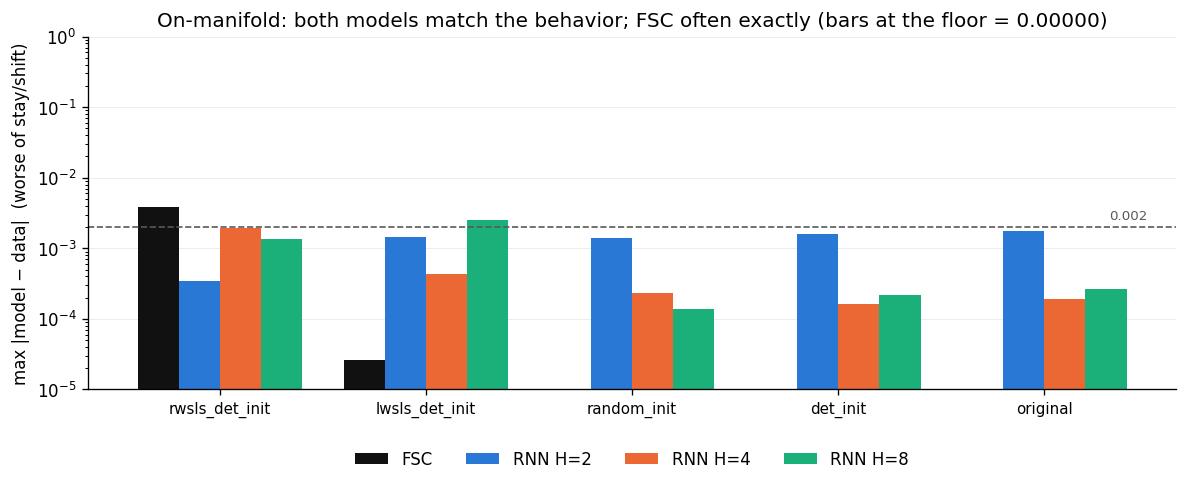

Win-stay / lose-shift rates  (real  |  FSC  |  RNN by H):

  rwsls_det_init
     P(stay|win) : data=0.6653  FSC=0.6691  H2=0.6655  H4=0.6656  H8=0.6645
     P(shift|lose): data=0.2008  FSC=0.2036  H2=0.2011  H4=0.2027  H8=0.2021

  lwsls_det_init
     P(stay|win) : data=1.0000  FSC=1.0000  H2=0.9992  H4=0.9997  H8=0.9998
     P(shift|lose): data=0.2004  FSC=0.2004  H2=0.1989  H4=0.2000  H8=0.1978

  random_init
     P(stay|win) : data=1.0000  FSC=1.0000  H2=0.9995  H4=0.9998  H8=0.9999
     P(shift|lose): data=1.0000  FSC=1.0000  H2=0.9986  H4=0.9998  H8=0.9999

  det_init
     P(stay|win) : data=1.0000  FSC=1.0000  H2=0.9995  H4=0.9999  H8=0.9999
     P(shift|lose): data=1.0000  FSC=1.0000  H2=0.9984  H4=0.9998  H8=0.9998

  original
     P(stay|win) : data=1.0000  FSC=1.0000  H2=0.9993  H4=0.9999  H8=0.9999
     P(shift|lose): data=1.0000  FSC=1.0000  H2=0.9982  H4=0.9998  H8=0.9997


In [60]:
# --- 1 -- how far each model's win-stay / lose-shift rate sits from the real data ----------
rows = []
for name in DATASETS:
    d = DATA[name]
    sw_d, sl_d = d["rate_data"]
    if d.get("rate_fsc"):
        rows.append((name, "FSC", abs(d["rate_fsc"][0]-sw_d), abs(d["rate_fsc"][1]-sl_d)))
    for H in d["rnn"]:
        rows.append((name, f"RNN H={H}", abs(d["rate_rnn"][H][0]-sw_d), abs(d["rate_rnn"][H][1]-sl_d)))
dev = pd.DataFrame(rows, columns=["dataset", "model", "|Δ P(stay|win)|", "|Δ P(shift|lose)|"])

fig, ax = plt.subplots(figsize=(10, 4.2))
models = ["FSC", "RNN H=2", "RNN H=4", "RNN H=8"]
mcolor = {"FSC": C_FSC, "RNN H=2": C_H[2], "RNN H=4": C_H[4], "RNN H=8": C_H[8]}
x = np.arange(len(DATASETS)); w = 0.2; FLOOR = 1e-5
for i, m in enumerate(models):
    vals = []
    for name in DATASETS:
        sub = dev[(dev["dataset"] == name) & (dev["model"] == m)]
        # worst of the two rates, floored so exact-zero still draws a visible stub
        vals.append(max(sub[["|Δ P(stay|win)|", "|Δ P(shift|lose)|"]].max(axis=1).max(), FLOOR)
                    if len(sub) else FLOOR)
    ax.bar(x + (i - 1.5) * w, vals, w, label=m, color=mcolor[m], edgecolor="none")
ax.set_yscale("log"); ax.set_ylim(FLOOR, 1)
ax.axhline(0.002, color=C_RULE, ls="--", lw=1)
ax.text(len(DATASETS)-0.5, 0.0023, "0.002", fontsize=8, color=C_RULE, va="bottom", ha="right")
ax.set_xticks(x); ax.set_xticklabels(DATASETS, fontsize=9)
ax.set_ylabel("max |model − data|  (worse of stay/shift)")
ax.set_title("On-manifold: both models match the behavior; FSC often exactly (bars at the floor = 0.00000)")
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.13))
ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

print("Win-stay / lose-shift rates  (real  |  FSC  |  RNN by H):")
for name in DATASETS:
    d = DATA[name]
    print(f"\n  {name}")
    print(f"     P(stay|win) : data={d['rate_data'][0]:.4f}"
          + (f"  FSC={d['rate_fsc'][0]:.4f}" if d.get('rate_fsc') else "")
          + "".join(f"  H{H}={d['rate_rnn'][H][0]:.4f}" for H in d["rnn"]))
    print(f"     P(shift|lose): data={d['rate_data'][1]:.4f}"
          + (f"  FSC={d['rate_fsc'][1]:.4f}" if d.get('rate_fsc') else "")
          + "".join(f"  H{H}={d['rate_rnn'][H][1]:.4f}" for H in d["rnn"]))

## 2. The probe: hand it a run of wins and watch its confidence fall

**The question.** §1 showed that ordinary trials cannot tell the two models apart. So we need an
extraordinary one. The idea: ask a question the training data never asked, and see whether each
model still gives the right answer.

**What "off the data manifold" means.** The data contains some situations and leaves out others. In
these 1000 sessions the longest run of wins in a row is 28, so a run of 50 wins never appears
anywhere. The set of situations the data does contain is what people call the data manifold, and 50
wins in a row sits outside it. Training can only score a model on situations it saw, so whatever a
model does outside that set costs it nothing. This section looks at what it does with that freedom.

**The probe.** Start the model from a blank memory. Feed it the same trial over and over: you picked
arm A, and you won. After each repeat, ask it one question, "how sure are you that you will stay on
A?" That number is `P(stay)`, and the chart plots it against `k`, the number of wins fed in so far.

**What the right answer looks like.** WSLS says win means stay. So the correct curve is a flat line
at 1.0 for every `k`, forever. Extra winning evidence cannot make staying less attractive. A model
that learned the rule has no other option available to it.

**What happens.** The FSC (black) draws that flat line. The RNN does not. Read the shading in two
tiers. The dark band covers the streak lengths that carry the training data's weight, up to `k=11`,
where 99% of all win streaks have ended; there the RNN holds at 0.95 or better. The light band runs
out to `k=28`, the single longest streak in 200,000 trials, and by then the collapsing arm is
already down to 0.71. Past that the two arms separate cleanly. One holds at 1.0 and the other keeps
sliding, reaching 0.23 by `k=80`. §5 shows that which arm breaks is decided by the random weights the network
started training from, so it says nothing about the task itself.

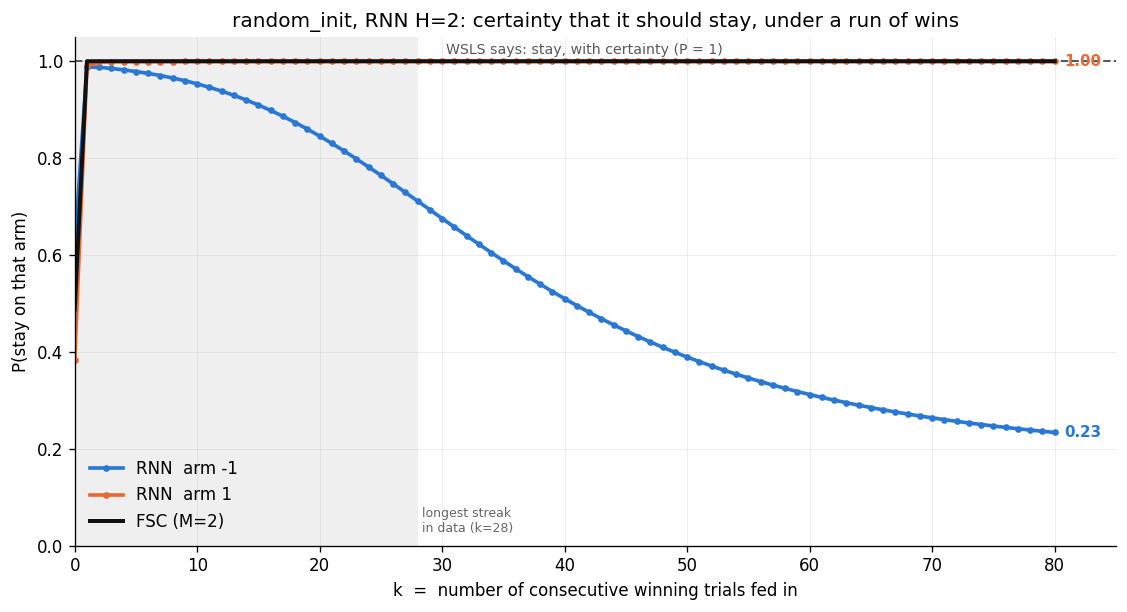

P(stay) at k=1 vs k=80   (should be 1.000 at both, per WSLS):
    arm -1:  0.988  ->  0.234   <-- collapses
     arm 1:  0.990  ->  1.000   (holds)
   FSC    :  1.000  ->  1.000   (flat, a lookup table)


In [61]:
# --- 2 -- the hero decay curve: P(stay) vs k on random_init, H=2, both arms + FSC ----------
d = DATA[HERO]; H = 2; A = d["A"]
fig, ax = plt.subplots(figsize=(9.5, 5.2))
shade_indata(ax, d["max_streak"], p99=d["p99_streak"])
ax.axhline(1.0, color=C_RULE, ls="--", lw=1.2)
ax.text(KMAX * 0.52, 1.008, "WSLS says: stay, with certainty (P = 1)", fontsize=8.5,
        color=C_RULE, ha="center", va="bottom")

for a0 in range(A):
    ax.plot(KGRID, d["probe"][H][a0]["pstay"], color=C_ARM[a0], lw=2.2,
            marker="o", ms=3, label=f"RNN  {arm_label(d, a0)}")
    ax.annotate(f"{d['probe'][H][a0]['pstay'][-1]:.2f}", (KMAX, d["probe"][H][a0]["pstay"][-1]),
                xytext=(6, 0), textcoords="offset points", color=C_ARM[a0], fontsize=9,
                va="center", fontweight="bold")
if d["fsc_probe"]:
    ax.plot(KGRID, d["fsc_probe"][0], color=C_FSC, lw=2.4, label=f"FSC (M={d['fsc']['M']})")

ax.set_xlim(0, KMAX + 5); ax.set_ylim(0, 1.05)
ax.set_xlabel("k  =  number of consecutive winning trials fed in")
ax.set_ylabel("P(stay on that arm)")
ax.set_title(f"{HERO}, RNN H={H}: certainty that it should stay, under a run of wins")
ax.legend(loc="lower left")
plt.tight_layout(); plt.show()

print(f"P(stay) at k=1 vs k={KMAX}   (should be 1.000 at both, per WSLS):")
for a0 in range(A):
    p = d["probe"][H][a0]["pstay"]
    print(f"   {arm_label(d, a0):>7s}:  {p[1]:.3f}  ->  {p[KMAX]:.3f}"
          + ("   <-- collapses" if p[KMAX] < 0.9 else "   (holds)"))
if d["fsc_probe"]:
    print(f"   FSC    :  {d['fsc_probe'][0][1]:.3f}  ->  {d['fsc_probe'][0][KMAX]:.3f}   (flat, a lookup table)")

## 3. What the internal state does while confidence falls

`P(stay)` reads out the hidden state `h`, so look at `h` directly. The left panel traces each
hidden unit over `k` for both arms. The right panel carries the result: the step size, the norm of
`h(k+1) - h(k)`, meaning how far the state still moves each time it receives the same input.

**Reading the left panel.** Two things are encoded at once. Color and weight give the arm, bold for
the collapsing arm and faded for the holding one. Line style gives the hidden unit, solid for unit 0
and dashed for unit 1. On `random_init` at `H=2` the collapsing arm's unit 0 locks at about -0.99 by
`k=2` and never moves again, while its unit 1 climbs from 0.15 to 0.95 across the full 80 steps.
That one creeping unit is the whole drift.

**Reading the right panel.** It plots speed, not position: how far the state moved on that step,
not where the state is. Winning and staying means nothing new to record, so a model that learned the
rule should stop moving, and its speed should go to zero and stay there. On a log axis zero has
nowhere to sit, so a settled model dives to the floor. A line held flat *above* the floor is the
failure case, because constant nonzero speed means the state keeps travelling forever under an
input that never changes.

The FSC does the right thing: it moves once, then reports exactly 0, so it pins to the floor. The
holding arm cuts its speed by a few times per step, 0.68 at `k=1` down to 3e-9 by `k=80`, parked.
The collapsing arm holds a steady 1e-2 and is still moving 2e-3 per step at `k=80`, nine decades
above the floor, which is what drags the readout from 0.99 to 0.23. It keeps writing to memory
although nothing new ever happened.

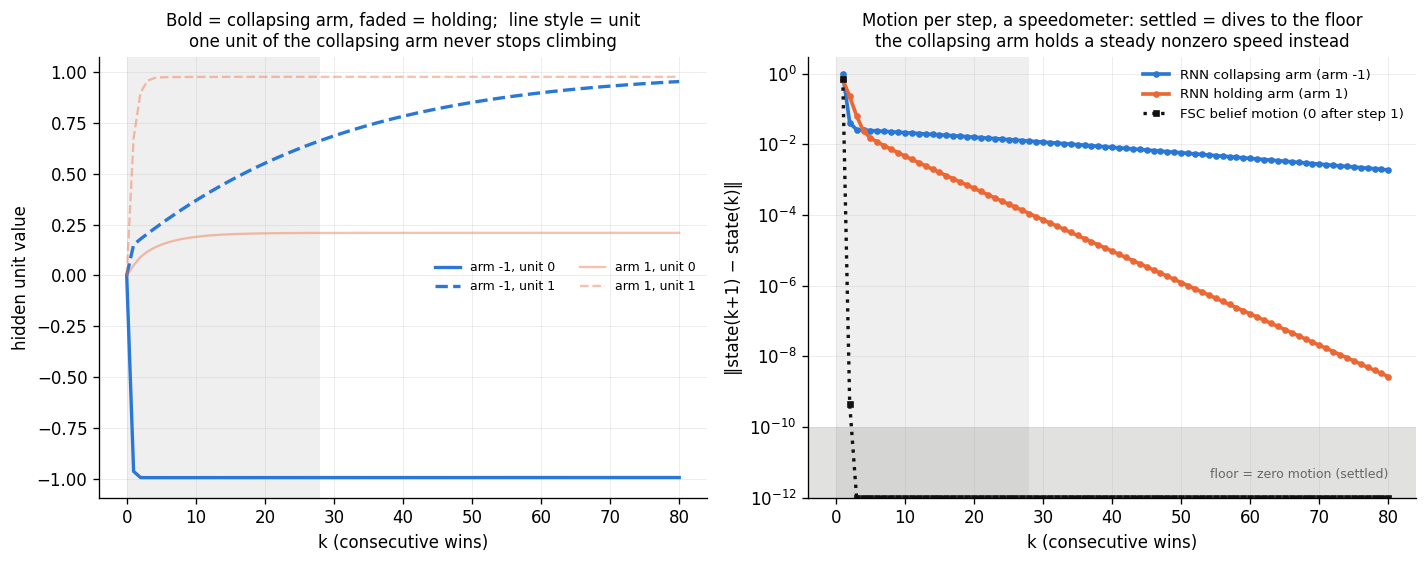

Holding arm  = arm 1  (fixed-point P(stay) = 1.000)
Collapsing arm = arm -1  (fixed-point P(stay) = 0.178)

Per-step motion ‖state(k+1) − state(k)‖  (0 = settled; a steady nonzero value = still drifting):
   collapsing (arm -1): k=1:9.7e-01  k=10:2.1e-02  k=28:1.2e-02  k=80:1.9e-03
   holding    (arm 1): k=1:6.8e-01  k=10:4.7e-03  k=28:1.1e-04  k=80:2.7e-09
   FSC belief       : k=1:7.2e-01  k=10:0.0e+00  k=28:0.0e+00  k=80:0.0e+00


In [69]:
# --- 3 -- hidden-state trajectory (left) and per-step motion (right) -----------------------
d = DATA[HERO]; H = 2; A = d["A"]
# identify which arm holds and which collapses, from the cached fixed points
fp = d["fp"][H]
hold_arm  = max(range(A), key=lambda a: fp[a]["pstay"])
drift_arm = min(range(A), key=lambda a: fp[a]["pstay"])

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.8))

# left: hidden components vs k. TWO encodings, do not confuse them:
#   color + weight = which arm (bold/saturated = collapsing, faded/thin = holding)
#   line style     = which hidden unit (solid = unit 0, dashed = unit 1)
for a0, style in [(drift_arm, dict(lw=2.0, alpha=1.0)), (hold_arm, dict(lw=1.4, alpha=0.4))]:
    hid = d["probe"][H][a0]["hidden"]
    for u in range(H):
        axL.plot(KGRID, hid[:, u], color=C_ARM[a0], ls=["-", "--"][u % 2],
                 label=(f"{arm_label(d, a0)}, unit {u}"), **style)
shade_indata(axL, d["max_streak"], label=False, p99=d["p99_streak"])
axL.set_xlabel("k (consecutive wins)"); axL.set_ylabel("hidden unit value")
axL.set_title("Bold = collapsing arm, faded = holding;  line style = unit\n"
              "one unit of the collapsing arm never stops climbing", fontsize=10)
axL.legend(fontsize=7.5, ncol=2, loc="best")

# right: step size ||dh|| vs k, log scale
for a0, lbl in [(drift_arm, "collapsing arm"), (hold_arm, "holding arm")]:
    hid = d["probe"][H][a0]["hidden"]
    dh = np.linalg.norm(np.diff(hid, axis=0), axis=1)
    axR.semilogy(KGRID[1:], np.clip(dh, 1e-12, None), color=C_ARM[a0], lw=2.2,
                 marker="o", ms=3, label=f"RNN {lbl} ({arm_label(d, a0)})")
if d["fsc_probe"]:
    # FSC belief motion: change in belief vector per step
    b = d["fsc"]["rho"].copy(); moves = []
    for _ in range(KMAX):
        bn = b @ d["fsc"]["TMat"][d["win_idx"], :, :, drift_arm]; s = bn.sum()
        bn = bn / s if s > 0 else b; moves.append(np.linalg.norm(bn - b)); b = bn
    axR.semilogy(KGRID[1:], np.clip(moves, 1e-12, None), color=C_FSC, lw=2.0, ls=":",
                 marker="s", ms=3, label="FSC belief motion (0 after step 1)")
shade_indata(axR, d["max_streak"], label=False, p99=d["p99_streak"])
axR.set_ylim(1e-12, 3)
axR.axhspan(1e-12, 1e-10, color=SHADE, alpha=0.25, lw=0, zorder=0)
axR.text(KMAX, 3e-12, " floor = zero motion (settled)", fontsize=7.5, color="0.4",
         ha="right", va="bottom")
axR.set_xlabel("k (consecutive wins)"); axR.set_ylabel("‖state(k+1) − state(k)‖")
# This is a SPEEDOMETER (motion per step), not the state itself. Log axis, so zero speed has
# nowhere to sit and a settled state dives to the floor. A line held flat ABOVE the floor is the
# failure: constant nonzero speed means the state keeps moving forever under an unchanging input.
axR.set_title("Motion per step, a speedometer: settled = dives to the floor\n"
              "the collapsing arm holds a steady nonzero speed instead", fontsize=10)
axR.legend(fontsize=8, loc="best")
plt.tight_layout(); plt.show()

print(f"Holding arm  = {arm_label(d, hold_arm)}  (fixed-point P(stay) = {fp[hold_arm]['pstay']:.3f})")
print(f"Collapsing arm = {arm_label(d, drift_arm)}  (fixed-point P(stay) = {fp[drift_arm]['pstay']:.3f})")
print("\nPer-step motion ‖state(k+1) − state(k)‖  (0 = settled; a steady nonzero value = still drifting):")
for a0, lbl in [(drift_arm, "collapsing"), (hold_arm, "holding   ")]:
    dh = np.linalg.norm(np.diff(d["probe"][H][a0]["hidden"], axis=0), axis=1)
    print(f"   {lbl} ({arm_label(d, a0)}): " + "  ".join(f"k={k}:{dh[k-1]:.1e}" for k in (1, 10, 28, KMAX)))
if d["fsc_probe"]:
    print(f"   FSC belief       : " + "  ".join(f"k={k}:{moves[k-1]:.1e}" for k in (1, 10, 28, KMAX)))

## 4. Why the network converges to the wrong fixed point

**The goal here.** §3 showed the memory never stops moving. Moving toward what? This section shows
three things: it is heading to one specific resting spot, that spot is the wrong answer, and it
travels there too slowly for training to ever notice.

**One word and one picture.** Feeding the same input forever turns the GRU into a single map applied
over and over. A **fixed point** is a state that map leaves alone, like the bottom of a bowl where a
marble rolls and then stays. How steep the bowl is gets measured by the **spectral radius**, the
factor by which a small nudge grows each step. Below 1 the nudge shrinks, the marble rolls back in,
and the spot is a genuine resting place. Close to 1 means a very shallow bowl and a very slow roll.
Measured on every dataset, size, and arm, it comes out below 1, so there is always exactly one
resting spot to talk about.

**The input alone picks that spot.** Set `h' = h` in the GRU update `h' = (1-z)·n + z·h` and it
collapses to `h* = n*`, the value the input proposes. The update gate `z` drops out of the equation.
It works as a brake, setting how fast the state arrives while having no say in where it arrives. So
the resting answer is `softmax(Linear(n*))`, whatever that comes out to, and nothing in the
architecture can pin it at 1.0.

**That spot is wrong, and it is wrong slowly.** On the collapsing arms the resting `P(stay)` sits
near 0.1 to 0.2, where WSLS demands 1.0. Their spectral radius is 0.96 to 0.99, just under the line,
so the bowl is shallow and the marble creeps.

Slow enough to matter: what training can punish is the streak lengths the data actually contains in
quantity, and win streaks here average 1.7 trials with 99% of them finished by 11. Out at `k=11` the
readout still says 0.95, so there is almost nothing for the loss to charge. The drift is well under
way by `k=28`, the one longest streak in the dataset, where the readout has already fallen to 0.71,
but a single trial out of 200,000 buys no gradient worth speaking of. Past that the same slow roll
continues, all the way down to 0.18.

So the RNN learned a different rule from the one in the data: after a long enough run of wins, drift
toward unsure or flip outright. The FSC has no way to fail like this, because its winning
memory-state points at itself, putting its resting spot exactly on the policy value after one lookup.

The chart below places every dataset, size, and arm at its resting `P(stay)`, so a model that
learned WSLS would put every marker on the dashed line at 1.0. The table adds each one's spectral
radius, which says how slowly it gets there.

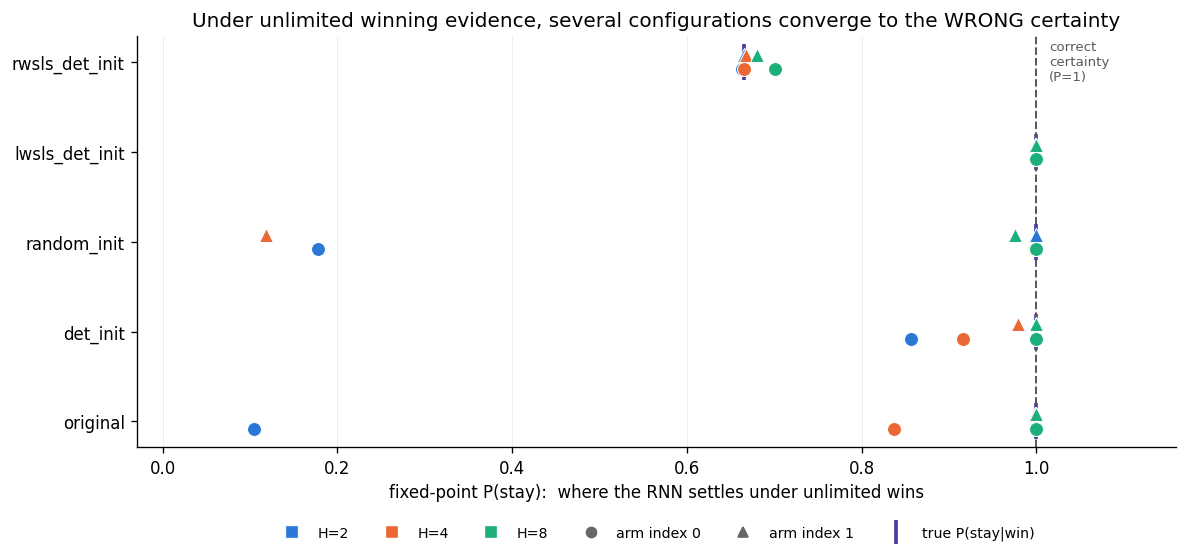

In [63]:
# --- 4a -- where UNLIMITED winning evidence actually takes each RNN (the fixed points) ------
# One row per dataset; each point is one (H, arm) configuration placed at its fixed-point P(stay).
# A model that learned WSLS would put every point on the "correct certainty" line. Marker shape =
# arm, color = hidden size. The violet tick is the dataset's TRUE P(stay|win) (=1.0 when the rule
# is deterministic, ~0.67 on the stochastic control) -- the value a correct model should converge to.
fig, ax = plt.subplots(figsize=(10, 4.8))
ymap = {name: i for i, name in enumerate(reversed(DATASETS))}   # most-deterministic on top
marker = {0: "o", 1: "^"}
# Give every (size, arm) its OWN lane inside the row. Most configurations land on 1.000, so a
# single lane per row buries five correct markers under one blob and the reader cannot tell
# whether they are looking at one point or six. Six lanes make the pile-up countable.
LANES = [(H, a0) for H in H_LIST for a0 in (0, 1)]
lane_y = {ha: (i - (len(LANES) - 1) / 2) * 0.115 for i, ha in enumerate(LANES)}
for name in DATASETS:
    d = DATA[name]; y = ymap[name]
    for H in d["rnn"]:
        for a0 in range(d["A"]):
            fpv = d["fp"][H][a0]["pstay"]
            ax.scatter(fpv, y + lane_y[(H, a0)], s=70, color=C_H[H], marker=marker[a0],
                       edgecolor="white", linewidth=0.6, zorder=3)
    ax.axhline(y, color="0.85", lw=0.7, zorder=0)          # a rail to read the row along
    ax.plot([d["rate_data"][0]], [y], marker="|", ms=34, color=C_TRUE, mew=2.2, zorder=2)
ax.axvline(1.0, color=C_RULE, ls="--", lw=1.2)
ax.text(1.015, len(DATASETS) - 1, "correct\ncertainty\n(P=1)",
        fontsize=8, color=C_RULE, ha="left", va="center")
ax.set_yticks(list(ymap.values())); ax.set_yticklabels(list(ymap.keys()))
ax.set_xlim(-0.03, 1.16); ax.set_xlabel("fixed-point P(stay):  where the RNN settles under unlimited wins")
ax.set_title("Under unlimited winning evidence, several configurations converge to the WRONG certainty\n"
             "each row holds 6 markers (3 sizes x 2 arms) in their own lanes; correct ones stack on the dashed line",
             fontsize=10)
# legends: color=H, shape=arm, tick=true rate
from matplotlib.lines import Line2D
h_handles = [Line2D([], [], marker="s", ls="", color=C_H[H], label=f"H={H}") for H in H_LIST]
a_handles = [Line2D([], [], marker=marker[a], ls="", color="0.4", label=f"arm index {a}") for a in (0, 1)]
t_handle  = [Line2D([], [], marker="|", ls="", color=C_TRUE, mew=2.2, ms=14, label="true P(stay|win)")]
ax.legend(handles=h_handles + a_handles + t_handle, ncol=6, loc="upper center",
          bbox_to_anchor=(0.5, -0.16), fontsize=8.5)
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

In [64]:
# --- 4b -- the fixed-point table: where unlimited winning evidence actually takes each RNN --
rows = []
for name in DATASETS:
    d = DATA[name]
    for H in d["rnn"]:
        for a0 in range(d["A"]):
            fp = d["fp"][H][a0]
            rows.append({
                "dataset": name, "H": H, "arm": str(d["ActSpace"][a0]),
                "P(stay) k=1":   round(float(d["probe"][H][a0]["pstay"][1]), 3),
                "P(stay) k=80":  round(float(d["probe"][H][a0]["pstay"][KMAX]), 3),
                "P(stay) fixed-pt": round(fp["pstay"], 3),
                "spectral radius":  round(fp["spec_radius"], 3),
                "verdict": ("correctly certain" if fp["pstay"] > 0.95 else
                            "drifts to WRONG certainty" if fp["pstay"] < 0.55 else
                            "partial drift"),
            })
fp_table = pd.DataFrame(rows)
# show the hero + the clearest failures first
print("Fixed-point analysis: the state each RNN settles into under UNLIMITED winning evidence.")
print("(WSLS requires P(stay) fixed-point = 1.000 on every deterministic dataset.)\n")
fp_table

Fixed-point analysis: the state each RNN settles into under UNLIMITED winning evidence.
(WSLS requires P(stay) fixed-point = 1.000 on every deterministic dataset.)



,dataset,H,arm,P(stay) k=1,P(stay) k=80,P(stay) fixed-pt,spectral radius,verdict
0,rwsls_det_init,2,-1,0.671,0.663,0.663,0.070,partial drift
1,rwsls_det_init,2,1,0.674,0.666,0.666,0.053,partial drift
2,rwsls_det_init,4,-1,0.692,0.665,0.665,0.217,partial drift
3,rwsls_det_init,4,1,0.574,0.668,0.668,0.226,partial drift
4,rwsls_det_init,8,-1,0.657,0.701,0.701,0.840,partial drift
5,rwsls_det_init,8,1,0.643,0.680,0.680,0.569,partial drift
6,lwsls_det_init,2,-1,1.000,1.000,1.000,0.303,correctly certain
7,lwsls_det_init,2,1,0.997,0.999,0.999,0.082,correctly certain
8,lwsls_det_init,4,-1,0.998,1.000,1.000,0.554,correctly certain
9,lwsls_det_init,4,1,0.999,0.999,0.999,0.620,correctly certain


## 5. Is the network simply too small?

**The objection.** Everything so far used the smallest network, two hidden units. The obvious
complaint is that two numbers of memory cannot hold a rule, and a bigger network would be fine.
This section tests that by running the same probe on `random_init` at 2, 4, and 8 hidden units.

**What the numbers say.** The resting `P(stay)` for each size and arm comes out as `H=2`: arm -1
lands at **0.178** while arm 1 holds at 1.000. `H=4`: arm -1 holds at 0.999 while arm 1 lands at
**0.119**. `H=8`: 1.000 and 0.975, so both arms hold.

Two things stand out. First, at `H=2` and `H=4` exactly one arm breaks, and it is a different arm
each time. The network has no reason to prefer one arm over the other, so the random weights it
started training from decide which one it sacrifices. Second, at `H=8` both arms hold, and the same
is true on the other four datasets: no `H=8` fit in the committed baseline set drifts.

**So does size fix it?** At this penalty setting, on these datasets, `H=8` does avoid the drift. Two
things keep that from being the reassuring answer it looks like.

- The extra units are not doing the work. The main pipeline measures how many directions of the
  hidden space a network actually uses, a quantity called the participation ratio. Think of it as
  asking how much of the memory earns its keep. The answer stays around 1.7 to 2.8 directions
  whether the network holds 2, 4, or 8 units. An `H=8` network runs on roughly as much memory as an
  `H=2` one.
- The fix does not survive a change in training settings. §6b runs the identical probe on `H=8` fits
  trained with a heavier weight penalty, and their worst arm falls from 0.98 to 0.52.

The honest summary: extra units move which arm breaks, and at `H=8` they land on a configuration
that holds. That outcome comes from where initialization and training happened to leave the weights,
and a small change to the training recipe undoes it.

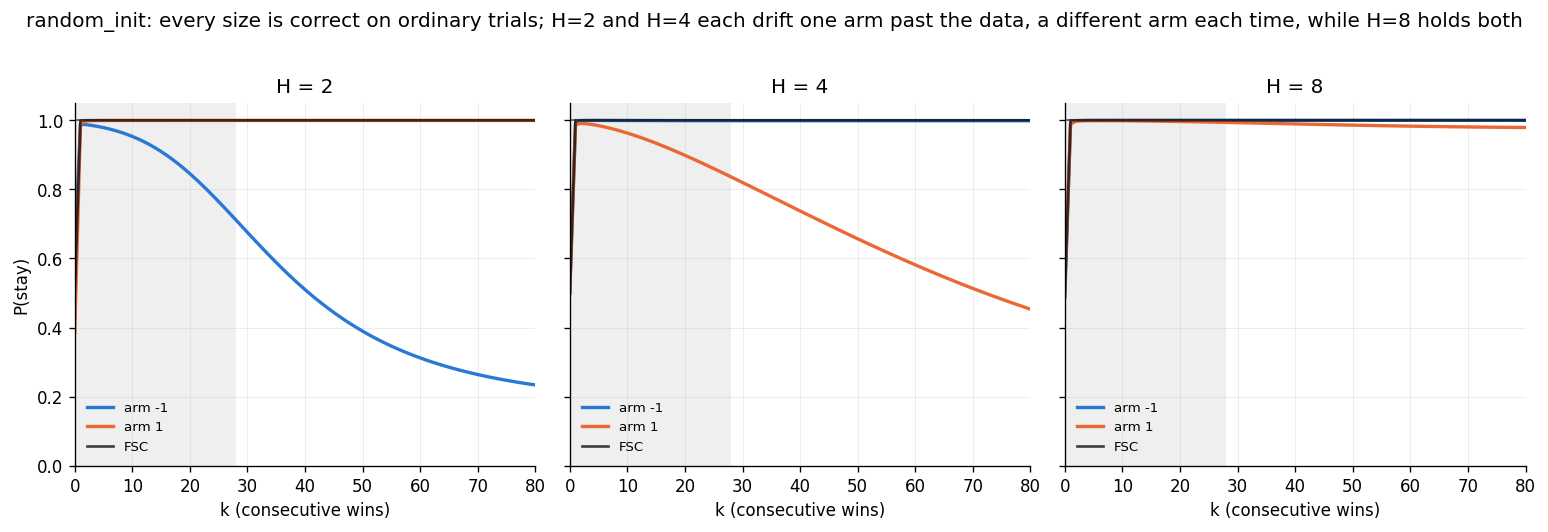

Fixed-point P(stay) per size and arm (which arm stays certain flips with size):
   H=2: arm -1=0.178   arm 1=1.000
   H=4: arm -1=0.999   arm 1=0.119
   H=8: arm -1=1.000   arm 1=0.975


In [65]:
# --- 5 -- same probe, three sizes: each holds one arm and drifts the other -----------------
d = DATA[HERO]; A = d["A"]
fig, axes = plt.subplots(1, len(H_LIST), figsize=(13, 4.3), sharey=True)
for ax, H in zip(axes, H_LIST):
    if H not in d["probe"]:
        ax.set_visible(False); continue
    shade_indata(ax, d["max_streak"], label=False, p99=d["p99_streak"])
    ax.axhline(1.0, color=C_RULE, ls="--", lw=1)
    for a0 in range(A):
        ax.plot(KGRID, d["probe"][H][a0]["pstay"], color=C_ARM[a0], lw=2.0,
                label=arm_label(d, a0))
    if d["fsc_probe"]:
        ax.plot(KGRID, d["fsc_probe"][0], color=C_FSC, lw=1.6, alpha=0.8, label="FSC")
    ax.set_xlim(0, KMAX); ax.set_ylim(0, 1.05)
    ax.set_title(f"H = {H}"); ax.set_xlabel("k (consecutive wins)")
    ax.legend(fontsize=8, loc="lower left")
axes[0].set_ylabel("P(stay)")
fig.suptitle(f"{HERO}: every size is correct on ordinary trials; H=2 and H=4 each drift one arm "
             "past the data, a different arm each time, while H=8 holds both", y=1.02)
plt.tight_layout(); plt.show()

print("Fixed-point P(stay) per size and arm (which arm stays certain flips with size):")
for H in d["rnn"]:
    print(f"   H={H}: " + "   ".join(f"{arm_label(d, a0)}={d['fp'][H][a0]['pstay']:.3f}" for a0 in range(A)))

## 6. The whole spectrum: what held and what drifted

**The question.** Every figure so far used one dataset. Does the drift appear everywhere, or did we
happen to pick a bad example?

**The five datasets.** All five are WSLS variants, and they differ in how strict the rule is. Four
of them follow "win means stay" every single time. One follows it only about two thirds of the time.
The panels run from the loosest rule (top-left) to the strictest (bottom). Each panel draws the
worst arm at each size, the FSC, and a dashed line at the rate the true rule implies, which is the
answer a correct model would settle on.

**The result, dataset by dataset.**

- `rwsls_det_init` is the control, and it is the one clean pass. Its real rule is random on purpose,
  staying after a win about 67% of the time. So the correct curve here is flat at 0.67, and that is
  where the RNN settles. Settling below 1.0 is the right answer when the truth is below 1.0. The
  problem shows up only where the truth is a hard certainty.
- `lwsls_det_init` demands a hard 1.0 on the win side and holds it at every size.
- `random_init`, `det_init`, and `original` also demand a hard 1.0. On all three, at least one arm
  at one size slides off that line once the input runs past what the data contained.

Put together: the drift is not tied to one dataset, and it is not universal either. It appears where
a model has to commit to a hard certainty off the data, and it disappears where the truth is a soft
rate the network can simply settle on.

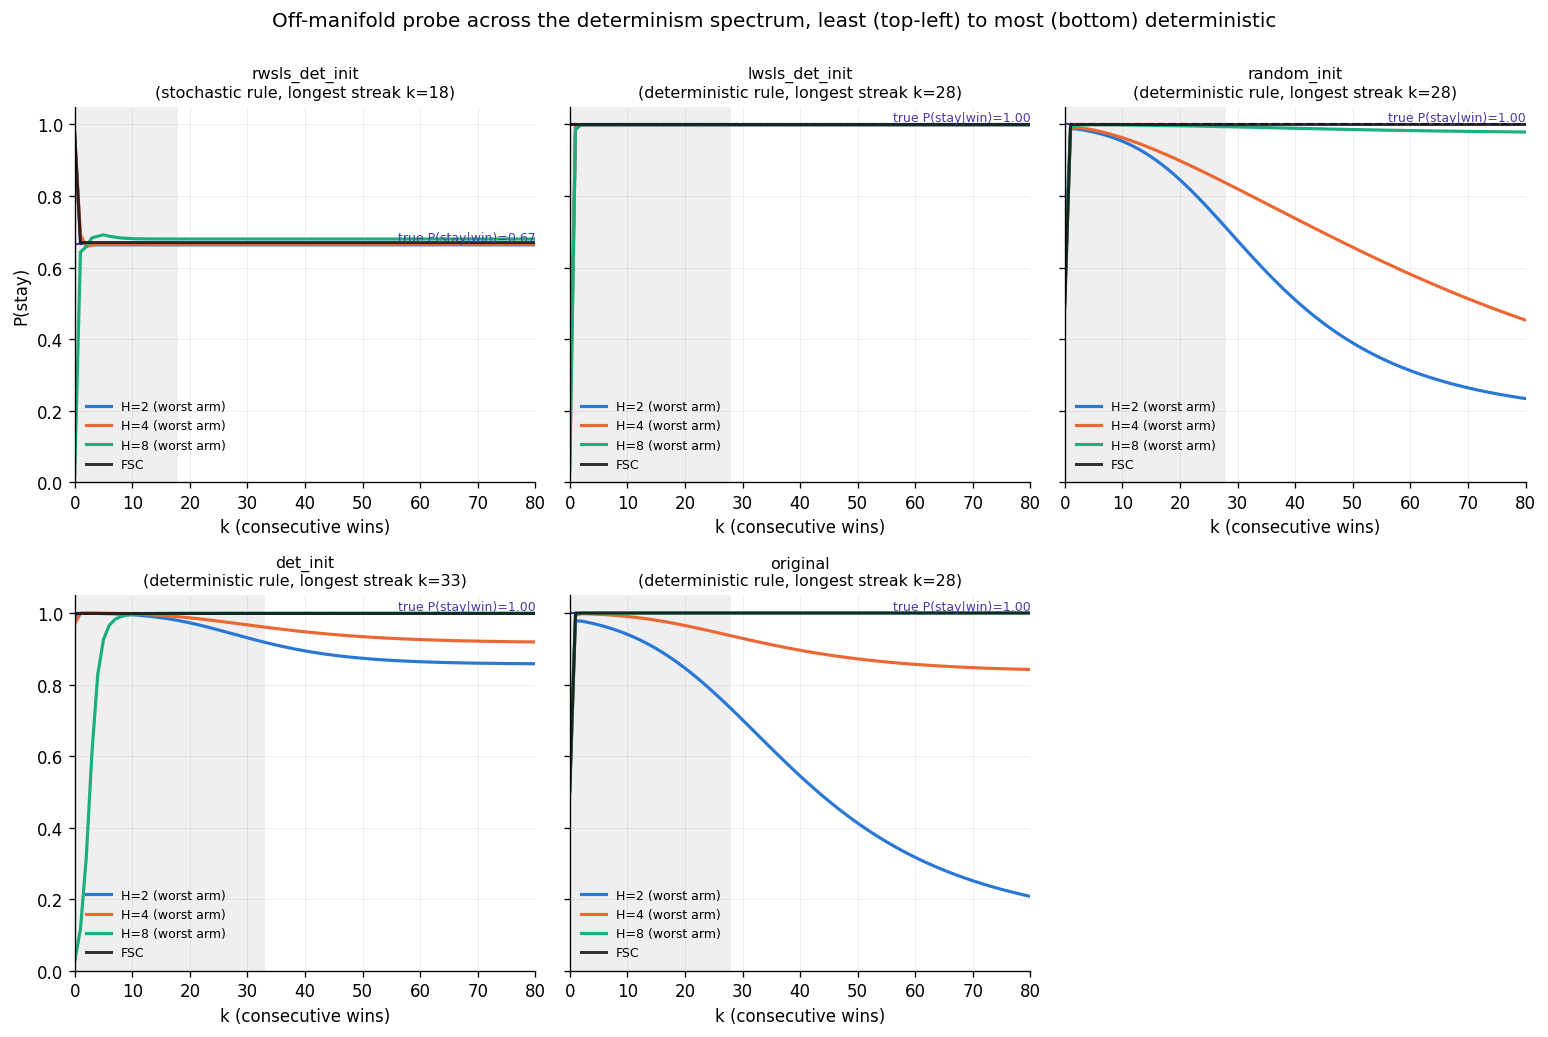

In [66]:
# --- 6 -- small-multiple grid: the probe across the determinism spectrum --------------------
ncol = 3; nrow = int(np.ceil(len(DATASETS) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(13, 4.3 * nrow), sharey=True)
axes = axes.ravel()
for ax, name in zip(axes, DATASETS):
    d = DATA[name]; A = d["A"]
    shade_indata(ax, d["max_streak"], label=False, p99=d["p99_streak"])
    true_sw = d["rate_data"][0]
    ax.axhline(true_sw, color=C_TRUE, ls="--", lw=1.3)
    ax.text(KMAX, true_sw, f" true P(stay|win)={true_sw:.2f}", fontsize=7.5,
            color=C_TRUE, ha="right", va="bottom")
    for H in d["rnn"]:
        # worst-drifting arm for this size = lowest fixed-point P(stay)
        a0 = min(range(A), key=lambda a: d["fp"][H][a]["pstay"])
        ax.plot(KGRID, d["probe"][H][a0]["pstay"], color=C_H[H], lw=1.9,
                label=f"H={H} (worst arm)")
    if d["fsc_probe"]:
        ax.plot(KGRID, d["fsc_probe"][0], color=C_FSC, lw=1.8, alpha=0.85, label="FSC")
    ax.set_xlim(0, KMAX); ax.set_ylim(0, 1.05)
    det = "stochastic rule" if true_sw < 0.95 else "deterministic rule"
    ax.set_title(f"{name}\n({det}, longest streak k={d['max_streak']})", fontsize=9.5)
    ax.set_xlabel("k (consecutive wins)"); ax.legend(fontsize=7.5, loc="lower left")
for ax in axes[len(DATASETS):]:
    ax.set_visible(False)
axes[0].set_ylabel("P(stay)")
fig.suptitle("Off-manifold probe across the determinism spectrum, least (top-left) to most (bottom) deterministic",
             y=1.0, fontsize=12)
plt.tight_layout(); plt.show()

### 6b. More regularization makes it worse

**The question.** Regularization is the standard way to push a network toward a simpler solution. If
the drift comes from the network being more complicated than it needs to be, a heavier penalty on
its weights should reduce it. Two datasets ship a second committed fit trained with a heavier L1
penalty on the recurrent weights, `1e-3` against the `1e-5` baseline: `random_init` from this
project, and `det_init` from the merged det-init branch. So we can check directly.

**How to compare fairly.** The two penalties give separately trained networks, and §5 showed each
network picks its own arm to sacrifice. Lining up arm -1 against arm -1 across them could compare a
broken arm to a healthy one and prove nothing. So we take each network's own worst arm and ask how
far that arm has fallen by `k=80`.

**The result.** The heavier penalty drifts further in five of the six dataset and size cells.
`random_init` gets worse at every size (`H=2` 0.23 to 0.02, `H=4` 0.45 to 0.33, `H=8` 0.98 to 0.52).
`det_init` gets worse at `H=2` (0.86 to 0.12) and at `H=8` (1.00 to 0.28), and improves in the one
remaining cell, `H=4` (0.92 to 0.99). Heavier regularization produces more off-manifold drift, which
runs opposite to the intuition it is usually applied on.

**How this fits with the rest of the project.** The main pipeline's §13 reports that this same
heavier penalty helps on ordinary trials. It makes the automatic size-selector decisive (p=0.029 to
p=0.004) and pulls the effective dimensionality back into line (participation ratio 2.85 to 1.82).
Both results hold at once. The penalty buys a tidier model on the data it trained on and pays for it
with worse behavior away from that data. The main pipeline's §9.3b shows the same drift effect on
`random_init`.

Searching for summary files...
Found 8 summary files.
Filtering by {'agent_type': 'RNN'}


100%|██████████| 8/8 [00:00<00:00, 938.19it/s]


Searching for summary files...
Found 8 summary files.
Filtering by {'agent_type': 'RNN'}


100%|██████████| 8/8 [00:00<00:00, 1119.04it/s]


Searching for summary files...
Found 8 summary files.
Filtering by {'agent_type': 'RNN'}


100%|██████████| 8/8 [00:00<00:00, 1843.35it/s]


Searching for summary files...
Found 8 summary files.
Filtering by {'agent_type': 'RNN'}


100%|██████████| 8/8 [00:00<00:00, 1908.02it/s]


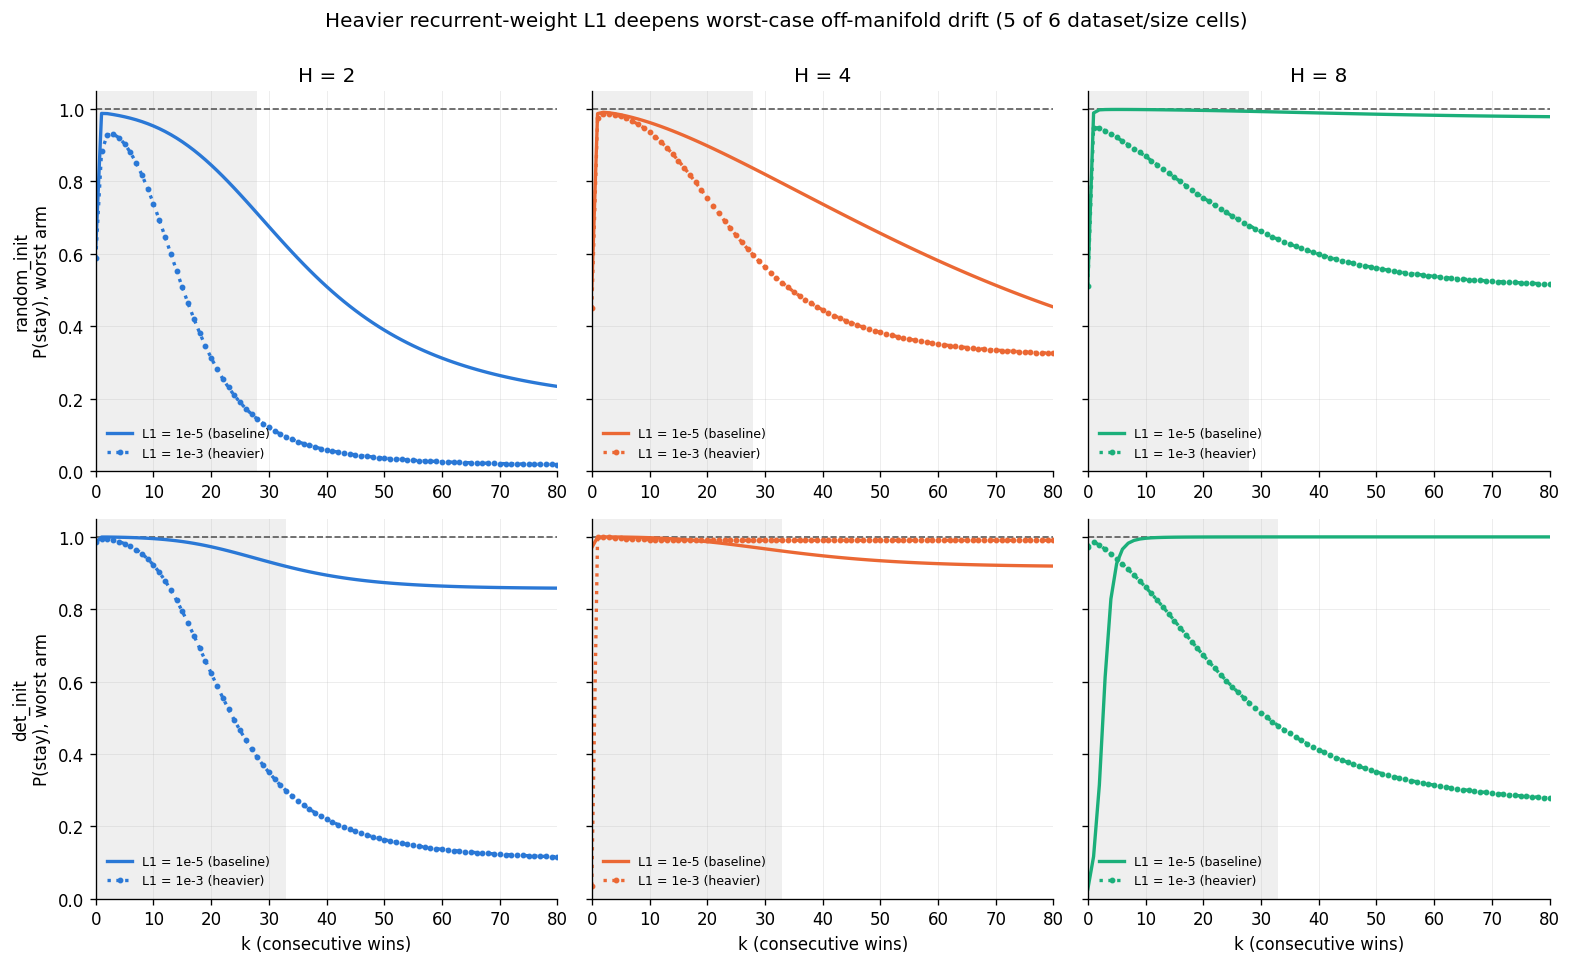

Worst-arm P(stay) at k=80  (lower = drifts further; * = heavier L1 drifts further):
  random_init
     H=2:  L1=1e-5 -> 0.234   L1=1e-3 -> 0.018   *
     H=4:  L1=1e-5 -> 0.453   L1=1e-3 -> 0.325   *
     H=8:  L1=1e-5 -> 0.979   L1=1e-3 -> 0.517   *
  det_init
     H=2:  L1=1e-5 -> 0.858   L1=1e-3 -> 0.116   *
     H=4:  L1=1e-5 -> 0.919   L1=1e-3 -> 0.990    
     H=8:  L1=1e-5 -> 1.000   L1=1e-3 -> 0.278   *


In [67]:
# --- 6b -- the same probe under a heavier L1 penalty, on every dataset that has an L1 sweep -
# Two datasets ship a committed L1=1e-3 sweep beside the 1e-5 baseline: random_init (this
# project) and det_init (added by the merged det-init branch). Each network breaks symmetry on
# its own arm (§5), so we compare each network's OWN worst arm: how far the more-drifting arm
# falls by k=KMAX. Rows are datasets, columns are hidden sizes.
L1_DATASETS = [name for name in ("random_init", "det_init")
               if load_rnn(name, DATA[name]["A"], DATA[name]["Y"], exp_suffix="_l1-0.001")]
_use_fsc_path()

def _worst_arm(probe_dict, H, A):        # lowest P(stay) at k=KMAX
    return min(range(A), key=lambda a: probe_dict[H][a]["pstay"][KMAX])

l1_probe = {}     # {dataset: {H: {arm: probe}}}
for name in L1_DATASETS:
    dd = DATA[name]
    rnn_l1 = load_rnn(name, dd["A"], dd["Y"], exp_suffix="_l1-0.001"); _use_fsc_path()
    l1_probe[name] = {H: {a0: rnn_probe(P, a0, dd["win_idx"], dd["A"], dd["Y"])
                          for a0 in range(dd["A"])} for H, P in rnn_l1.items()}

fig, axes = plt.subplots(len(L1_DATASETS), len(H_LIST),
                         figsize=(4.4 * len(H_LIST), 4.0 * len(L1_DATASETS)), sharey=True, squeeze=False)
worse = total = 0
for r, name in enumerate(L1_DATASETS):
    dd = DATA[name]; A = dd["A"]
    for c, H in enumerate(H_LIST):
        ax = axes[r, c]
        if H not in dd["probe"] or H not in l1_probe[name]:
            ax.set_visible(False); continue
        shade_indata(ax, dd["max_streak"], label=False, p99=dd["p99_streak"])
        ax.axhline(1.0, color=C_RULE, ls="--", lw=1)
        ab = _worst_arm(dd["probe"], H, A)
        al = _worst_arm(l1_probe[name], H, A)
        base_end, l1_end = dd["probe"][H][ab]["pstay"][KMAX], l1_probe[name][H][al]["pstay"][KMAX]
        total += 1; worse += (l1_end < base_end)
        ax.plot(KGRID, dd["probe"][H][ab]["pstay"], color=C_H[H], lw=2.0, label="L1 = 1e-5 (baseline)")
        ax.plot(KGRID, l1_probe[name][H][al]["pstay"], color=C_H[H], lw=2.0, ls=":", marker="o",
                ms=2.5, label="L1 = 1e-3 (heavier)")
        ax.set_xlim(0, KMAX); ax.set_ylim(0, 1.05)
        if r == 0: ax.set_title(f"H = {H}")
        if r == len(L1_DATASETS) - 1: ax.set_xlabel("k (consecutive wins)")
        ax.legend(fontsize=7.5, loc="lower left")
    axes[r, 0].set_ylabel(f"{name}\nP(stay), worst arm")
fig.suptitle("Heavier recurrent-weight L1 deepens worst-case off-manifold drift "
             f"({worse} of {total} dataset/size cells)", y=1.0)
plt.tight_layout(); plt.show()

print(f"Worst-arm P(stay) at k={KMAX}  (lower = drifts further; * = heavier L1 drifts further):")
for name in L1_DATASETS:
    dd = DATA[name]; A = dd["A"]
    print(f"  {name}")
    for H in H_LIST:
        if H not in dd["probe"] or H not in l1_probe[name]:
            continue
        b = dd["probe"][H][_worst_arm(dd["probe"], H, A)]["pstay"][KMAX]
        l = l1_probe[name][H][_worst_arm(l1_probe[name], H, A)]["pstay"][KMAX]
        print(f"     H={H}:  L1=1e-5 -> {b:.3f}   L1=1e-3 -> {l:.3f}   {'*' if l < b else ' '}")

## 7. What this adds up to

**1. Matching behavior does not prove a model learned the rule.** On every dataset, across the
trials that actually occur, the FSC and the RNN land within about 0.002 of the real win-stay and
lose-shift rates (§1). On behavior alone they read as interchangeable, and that reading is wrong.

**2. The RNN never learned "always stay".** Feed it a run of wins longer than any streak in the
data and its confidence that it should stay falls (§2). The FSC answers 1.0 forever, because it
looks the answer up from `(action, observation)` and has no off-manifold behavior to get wrong.

**3. It learned a slow slide toward the wrong resting place.** On the failing arm the memory keeps
moving where a learned rule would have gone quiet (§3). Under unlimited winning evidence the network
settles, stably, on a state whose readout is the wrong certainty, often near-random or flipped (§4).
The pull is weak, spectral radius 0.96 to 0.99, so the slide is slow: at `k=11`, where 99% of the
data's win streaks have ended, the readout still reads 0.95. Training had almost nothing to charge
it for.

**4. Capacity is not the story.** Every size gets WSLS right on ordinary trials. At `H=2` and `H=4`
one arm drifts, a different arm each time, decided by the random starting weights (§5). At `H=8` the
baseline fits hold both arms on all five datasets, so extra units do avoid the drift here. Two
things stop that from being a fix: the participation ratio says these networks use only about 1.7 to
2.8 directions of memory whatever their size, and a heavier weight penalty sends `H=8` back to 0.52
on `random_init` (§6b).

**5. The one clean case is the one that needs no certainty.** On the control dataset
`rwsls_det_init`, the true rule stays after a win about 67% of the time, and the RNN settles right
there (§6). So the failure is specific. The network cannot hold a hard 0 or 1 away from the data,
even for a one-bit rule it saw across 1000 sessions.

**For the project.** A small discrete controller and a small GRU can produce identical behavior
while computing different things underneath. The FSC represents the rule. The RNN approximates it
wherever the data lives. Any claim that "the RNN learned the strategy" has to be tested away from
the data, because behavior on ordinary trials cannot separate the two. The probe is the tool that
makes the gap visible.

**Scope.** All five datasets are one-bit WSLS variants. That makes them the right setting to
validate the diagnostic, since we know the correct answer and the probe recovers it. It makes them
the wrong setting for claims about when RNN capacity pays off. The next test needs a task with real
multi-step memory.